In [2]:
import numpy as np
import gymnasium as gym
import importlib
import envs

import learners
import analysis
importlib.reload(analysis)
importlib.reload(learners)
from learners import *
from analysis import *

params = Params(
    model_name="Walkway",
    n_runs=1,
    n_episodes=20_000,
    save_skip=50,
    lr_decay=None,
    seed=123,
    
    N=32,
    alpha=0.2,
    gamma=0.5,
    epsilon=0.0,
    kappa=0.0,
    
    nA=None,
    nS=None,
    shape=None,
)
rng = np.random.default_rng(params.seed)
tau = (np.arange(params.N) + 0.5) / params.N
MoG = MixtureOfGaussians([1/2, 1/2], [-1, 3], [1, 1], rng)
env = gym.make(
    params.model_name,
    MoG=MoG,
    shape=(1,3),
)
params = params._replace(nA=int(env.action_space.n))
params = params._replace(nS=int(env.observation_space.n))
params = params._replace(shape=env.unwrapped.shape)
s_init, _ = env.reset()

In [4]:
policy, V_pi = PolicyIteration(env, params.gamma)
explorer = EpsilonGreedy(rng)

def get_exp_scheduler(alpha, n_ep_decay, min_val=0.005): return lambda t: max(alpha * 0.5**(t/n_ep_decay), min_val)
scheduler = get_exp_scheduler(params.alpha, 1250, min_val=0.00025)

table0 = QR(params, policy).train(env, explorer, scheduler)
# table1 = QR(1, params, policy).train(env, explorer, scheduler)
# qtable = Qlearner(params, policy).train(env, explorer, scheduler)

100%|██████████| 20000/20000 [00:19<00:00, 1028.79it/s, run=1, t=2e+4] 


In [47]:
def get_q(table): return table[:,:,s_init, policy[s_init].argmax()]
def get_best(table): return get_q(table)[:,-1].mean(0)

def custom_pdf(plot_objs, returns=None, bandwidth=0.08, figsize=(5,4), show_hist=False, x_spacing=0.03, N=32, save_to=None, hist_alpha=0.2, include_legend=False, linewidth=1.0, ylabel=None, returns_name=MC_NAME, color_idx=0, height=3, plot_name="pdf_compare"):
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=figsize)
    if ylabel is None:
        fig.supylabel("Estimated Value Distribution", fontweight="bold", fontsize="large")
    else:
        fig.supylabel(ylabel, fontweight="bold", fontsize="large")        

    all_data = returns
    bins = np.histogram_bin_edges(all_data, bins=N)
    xmin, xmax = all_data.min(), all_data.max()
    x_add = max(np.abs(xmin), np.abs(xmax))*x_spacing
    Xs = np.linspace(xmin - x_add, xmax + x_add, 500)
    ticks = None
    if returns is not None:
        ax.plot(Xs, get_kde(returns, bandwidth=bandwidth)(Xs), label=returns_name, linestyle="--", linewidth=2, color=COLORS[0])
        ax.fill_between(Xs, np.zeros(len(Xs)), get_kde(returns, bandwidth=bandwidth)(Xs), color=COLORS[0], alpha=hist_alpha)
    
    for idx, (quantile, name) in enumerate(plot_objs):
        ax.plot(Xs, get_kde(quantile, bandwidth=bandwidth)(Xs), label=name, color=COLORS[idx+1+color_idx], linewidth=linewidth)
        # if show_hist: ax.hist(quantile, bins=bins, density=True, alpha=hist_alpha, color=COLORS[idx+1+color_idx])
        ax.fill_between(Xs, np.zeros(len(Xs)), get_kde(quantile, bandwidth=bandwidth)(Xs), color=COLORS[idx+1+color_idx], alpha=hist_alpha)

        ticks = ax.get_yticks()
        
        abslen= abs(ticks[0] - ticks[-1])
        HEIGHT = abslen*height
        
        R_init = ticks[-1]
        R_height = ticks[-1]-HEIGHT

        R = returns
        ax.plot(
            [R, R],
            [R_height, R_init],
            color=COLORS[0],
            linewidth=1.2
        )

        # circle at the top
        ax.plot(
            [R],
            [R_height],
            marker='o',
            color=COLORS[0],
            markersize=5
        )


        Y = quantile
        # ax.plot(np.stack([Y, Y]), np.stack([Y * 0, Y * 0 + 1.0]), "ro-");
        
        ax.plot(
            [Y, Y],
            [0, HEIGHT],
            color=COLORS[idx+1+color_idx],
            linewidth=1.2
        )

        # circle only at the top
        ax.plot(
            [Y],
            [HEIGHT],
            marker='o',
            color=COLORS[idx+1+color_idx],
            markersize=5
        )
        
    if ticks is not None:
        ax.set_ylim(0.0, ticks[-1])
    ax.set_xlim((Xs.min(), Xs.max()))
    ax.set_xlabel("Returns", fontweight="bold", fontsize="large")
    ax.grid(True)
    if include_legend: ax.legend(prop={"weight":"bold", "size":"large"})
    plt.tight_layout()
    
    if save_to is not None:
        Path(save_to).mkdir(parents=True, exist_ok=True)
        plt.savefig(f"{save_to}/{plot_name}.png", format="png", bbox_inches="tight")

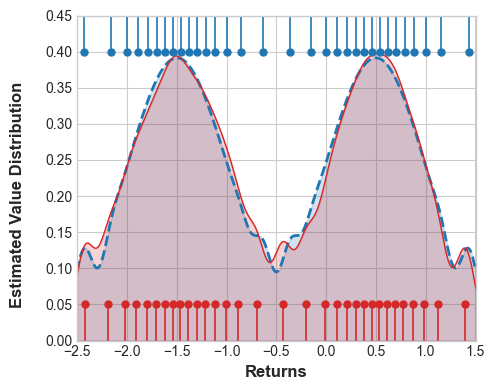

In [67]:
tau_true = (env.unwrapped.rewards["step"] + params.gamma * MoG.ppf(tau))
save_to = None

ep = 399
custom_pdf([(table0[0,ep,s_init,policy[s_init].argmax()], "QR-0")],
         tau_true, bandwidth=0.1, hist_alpha=.2, height=0.1, save_to="results/method/quantile_showcase", plot_name=f"quantile_showcase_ep{ep}")